In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Exercise 1: Hasting-Metropolis within Gibbs – Stochastic Approximation EM

## 1.A – A population model for longitudinal data

### 1.

The parameters of the model are
$\theta = (\bar t_0, \bar v_0, \sigma_\xi, \sigma_\tau, \sigma)$.

The latent variables are the fixed effects
$z_{pop}=(t_0,v_0)$ and the random effects $z_i=(\alpha_i,\tau_i)$.

The observed variables are the
$$y_{i,j}=p_0+v_0\alpha_i(t_{i,j}-t_0-\tau_i)+\varepsilon_{i,j}$$

The likelihood of the model is
$$q(y,z,\theta)=q(y|z,\theta)\;q(z_{pop}|\theta)\;q((z_i)_i|\theta)\;q_{prior}(\theta)$$
We now decompose each one of the four factors.

* $q(y|z,\theta)$


For all $i$ and $j$, knowing $z$ and $\theta$, we have
$$y_{i,j}=d_i(t_{i,j})+\varepsilon_{i,j}\sim^{i.i.d} \mathcal N(d_i(t_{i,j}), \sigma^2)$$
so
$$q(y|z,\theta)=\prod_{i,j}\frac{1}{\sqrt{2\pi}\sigma} \exp\Big(-\frac{(y_{i,j}-d_i(t_{i,j}))^2}{2\sigma^2}\Big)$$
and going to the log gives
$$\boxed{\log q(y|z,\theta)=-\frac{K}{2}\log(2\pi)-K\log\sigma-\sum_{i,j}\frac{(y_{i,j}-d_i(t_{i,j}))^2}{2\sigma^2}}$$
where $K=\sum_i k_i$.

* $q(z_{pop}|\theta)$

We have $t_0\sim \mathcal N(\bar t_0, \sigma_{t_0}^2)$ and $v_0\sim \mathcal N(\bar v_0, \sigma_{v_0}^2)$ independent, so
$$\boxed{\log q(z_{pop}|\theta) =-\frac{1}{2} \log(2\pi\sigma_{t_0}^2)-\frac{1}{2} \log(2\pi\sigma_{v_0}^2)-\frac{(t_0-\bar t_0)^2}{2\sigma_{t_0}^2}-\frac{(v_0-\bar v_0)^2}{2\sigma_{v_0}^2}}$$

* $q((z_i)_i|\theta)$

The random effects are independent for all $i$, and we have $\alpha_i=\exp\xi_i$ where $\xi_i\sim\mathcal N(0,\sigma_\xi^2)$ and $\tau_i\sim\mathcal N(0,\sigma_\tau^2)$. Thus
$$q(z_i|\theta)=\frac{1}{\sqrt{2\pi}\sigma_\xi}\exp\Big(-\frac{(\log \alpha_i)^2}{2\sigma_\xi^2}\Big)\frac{1}{\sqrt{2\pi}\sigma_\tau}\exp\Big(-\frac{\tau_i^2}{2\sigma_\tau^2}\Big)$$
Hence
$$\boxed{\log q((z_i)_i|\theta)=-N \log(2\pi)-N \log\sigma_\xi-N\log\sigma_\tau-\sum_i \frac{(\log \alpha_i)^2}{2\sigma_\xi^2}-\sum_i \frac{\tau_i^2}{2\sigma_\tau^2}}$$

* $q_{prior}(\theta)$

From the prior given, and the definition of the inverse-Wishart distribution, we have
$$\log q_{prior}(\theta)=-\log(2\pi)-\log s_{t_0}-\log s_{v_0}-\frac{(\bar t_0-\bar{\bar t}_0)^2}{2s_{t_0}^2}-\frac{(\bar v_0-\bar{\bar v}_0)^2}{2s_{v_0}^2}-\log\Gamma(m_\xi/2)-2\log\sigma_\xi+m_\xi\log v_\xi-m_\xi\log\sigma_\xi-\frac{m_\xi}{2}\log 2-\frac{v_\xi^2}{2\sigma_\xi^2}+...$$

Combining all the terms, we get
$$\log q(y,z,\theta)=-K \log\sigma-\sum_{i,j}\frac{(y_{i,j}-d_i(t_{i,j}))^2}{2\sigma^2}-\frac{(t_0-\bar t_0)^2}{2\sigma_{t_0}^2}-\frac{(v_0-\bar v_0)^2}{2\sigma_{v_0}^2}-N \log\sigma_\xi-N\log\sigma_\tau-\sum_i \frac{(\log \alpha_i)^2}{2\sigma_\xi^2}-\sum_i \frac{\tau_i^2}{2\sigma_\tau^2}-\frac{(\bar t_0-\bar{\bar t}_0)^2}{2s_{t_0}^2}-\frac{(\bar v_0-\bar{\bar v}_0)^2}{2s_{v_0}^2}-2\log\sigma_\xi-m_\xi \log\sigma_\xi-\frac{v_\xi^2}{2\sigma_\xi^2}-2\log\sigma_\tau-m_\tau \log\sigma_\tau-\frac{v_\tau^2}{2\sigma_\tau^2}-2\log\sigma-m \log\sigma-\frac{v^2}{2\sigma^2}+C$$
where $C$ is a fixed term.

We can write the log-likelihood as
$$\log q(y,z,\theta)=\langle S(y,z), \Psi(\theta)\rangle - \Phi(\theta)+B(y,z) $$
where the sufficient statistics are:
* $S_1=\frac{1}{K}\sum_{i,j} (y_{i,j}-d_i(t_{i,j}))^2$
* $S_2=t_0$
* $S_3=v_0$
* $S_4=\frac{1}{N}\sum_i (\log \alpha_i)^2$
* $S_5=\frac{1}{N}\sum_i \tau_i^2$

the natural parameters are:
* $\Psi_1=-K/(2\sigma^2)$
* $\Psi_2=\bar t_0/\sigma_{t_0}^2$
* $\Psi_3=\bar v_0/\sigma_{v_0}^2$
* $\Psi_4=-N/(2\sigma_\xi^2)$
* $\Psi_4=-N/(2\sigma_\tau^2)$

and the log-partition function is
$$\Phi(\theta)=K\log\sigma+\frac{\bar t_0^2}{2\sigma_{t_0}^2}+\frac{\bar v_0^2}{2\sigma_{v_0}^2}+N \log\sigma_\xi+N\log\sigma_\tau+...$$

Thus, the model belongs to the curved exponential family.

### 2.

In [20]:
SIGMA_t_0 = 0.1
SIGMA_v_0 = 0.1
P_0 = 1

def generate_z_knowing_theta(theta, N):
  '''Generate z_pop and N samples of z_i knowing theta.
  Returns z_pop as a tuple and z_i as an array of shape (N,2)'''
  bar_t_0, bar_v_0, sigma_xi, sigma_tau, sigma = theta

  # Generate z_pop
  t_0 = np.random.normal(loc=bar_t_0, scale=SIGMA_t_0)
  v_0 = np.random.normal(loc=bar_v_0, scale=SIGMA_v_0)
  z_pop = (t_0, v_0)

  # Generate z_i
  xi = np.random.normal(loc=0, scale=sigma_xi, size=N)
  alpha = np.exp(xi)
  tau = np.random.normal(loc=0, scale=sigma_tau, size=N)
  z_i = np.stack((alpha, tau), axis=-1)

  return z_pop, z_i

def generate_y_knowing_z_theta(z_pop, z_i, theta, K, T):
  '''Generate y knowing z_pop, z_i and theta. Also requires the number of measurements (k_i)
  as an array of size N and the times of measurement t_{i,j} as an array of shape (N, max k_i).
  Returns y_{i,j} as an array of shape (N, max k_i).'''
  _, _, _, _, sigma = theta
  t_0, v_0 = z_pop
  alpha = z_i[:,0]
  tau = z_i[:,1]
  N = len(z_i)
  assert len(K) == N
  max_k = np.max(K)
  assert T.shape == (N, max_k)

  # Sample epsilons
  epsilons = np.random.normal(loc=0, scale=sigma, size=(N, max_k))

  Y = P_0 + v_0 * alpha[:,None] * (T - t_0 - tau[:,None]) + epsilons

  return Y

In [21]:
# For the sampling, we chose N = 1000, k_i = 100 for all i
# and regularily spaced t
N = 100
K = np.full(N, 20)
T = np.tile(np.linspace(0, 10, 20), (N, 1))

theta = (1, 1, 0.5, 0.5, 0.5)

z_pop, z_i = generate_z_knowing_theta(theta, N)
y = generate_y_knowing_z_theta(z_pop, z_i, theta, K, T)

## 1.B – HM-SAEM – Hasting-Metropolis sampler

### 3.

We want to sample from the distribution $(z|y,\theta)$. From Bayes formula, we have that
$$p(z|y,\theta)=\frac{q(y,z|\theta)}{q(y|\theta)}$$
Thus, our target distribution is
$$\pi(z)\propto q(y,z|\theta)$$
Using the expression for the likelihoods obtained in question 1, we have
$$\pi(z)\propto \prod_{i,j} \exp\Big(-\frac{(y_{i,j}-d_i(t_{i,j}))^2}{2\sigma^2}\Big)\times \prod_i\exp\Big(-\frac{\xi_i^2}{2\sigma_\xi^2}\Big)\exp\Big(-\frac{\tau_i^2}{2\sigma_\tau^2}\Big)\times \exp\Big(-\frac{(t_0-\bar t_0)^2}{2\sigma_{t_0}^2}\Big)\exp\Big(-\frac{(v_0-\bar v_0)^2}{2\sigma_{v_0}^2}\Big)$$
We thus define the unnormalized log target function
$$\log f(z)=-\frac{1}{2\sigma^2}\sum_{i,j}(y_{i,j}-d_i(t_{i,j}))^2-\frac{1}{2\sigma_\xi^2}\sum_i \xi_i^2-\frac{1}{2\sigma_\tau^2}\sum_i\tau_i^2-\frac{(t_0-\bar t_0)^2}{2\sigma_{t_0}^2}-\frac{(v_0-\bar v_0)^2}{2\sigma_{v_0}^2}$$

The resulting algorithm for the proposal distribution $q(\cdot|\theta)=\mathcal N(z,\sigma_{prop})$ is:

1. Given an initial state $z^{(0)}=(t_0^{(0)}, v_0^{(0)}, \xi_1^{(0)}, ..., \xi_N^{(0)},\tau_1^{(1)},..., \tau_N^{(0)})$
2. For $k=0$:
    1. Sample $z^*\sim \mathcal N(z^{(k)},\sigma_{prop})$
    2. Sample $u\sim \mathcal U([0,1])$
    3. Calculate the acceptance ratio:
    $$\alpha= \min\Big(1, \exp(\log f(z^*)-\log f(z^{(k)})\Big)$$
    where $\log f$ is the unnormalized log target function we have just defined
    4. If $u\le \alpha$, set $z^{(k+1)}=z^*$
    5. Else, set $z^{(k+1)}=z^{(k)}$



We now implement the algorithm, which will be useful for newt question.

In [22]:
def logf(z, y, theta, t):
  '''Compute the unnormalized log target function defined in question 3.
  Requires z, y, theta and the array t of the measurement times.'''
  bar_t_0, bar_v_0, sigma_xi, sigma_tau, sigma = theta
  (t_0, v_0), z_i = z
  alpha = z_i[:,0]
  tau = z_i[:,1]
  N = len(z_i)

  # If one alpha has a negative value, then log f will be equal to -infinity
  if np.min(alpha) <= 0:
    return -np.inf

  return ( \
    - 1/(2*sigma**2) * np.sum((y - P_0 - v_0 * alpha[:,None] * (t - t_0 - tau[:,None]))**2) \
    - 1/(2*sigma_xi**2) * np.sum(np.log(alpha)**2) \
    - 1/(2*sigma_tau**2) * np.sum(tau**2) \
    - (bar_t_0 - t_0)**2 / (2*SIGMA_t_0**2) \
    - (bar_v_0 - v_0)**2 / (2*SIGMA_v_0**2)
  )


def metropolis_hastings_sampler_step(z, sigma_prop, y, theta, t):
  '''Run one step of the algorithm described in question 3.
  Requires z, sigma_prop, y, theta and the array t of the measurement times.'''
  (t_0, v_0), z_i = z
  alpha = z_i[:,0]
  tau = z_i[:,1]
  N = len(z_i)

  # Sample proposed z^*
  proposed_t_0 = t_0 + np.random.normal(scale=sigma_prop)
  proposed_v_0 = v_0 + np.random.normal(scale=sigma_prop)
  proposed_xi = np.log(alpha) + np.random.normal(scale=sigma_prop, size=N)
  proposed_tau = tau + np.random.normal(scale=sigma_prop, size=N)
  proposed_z = ((proposed_t_0, proposed_v_0), np.stack((np.exp(proposed_xi), proposed_tau), axis=-1))

  # Sample u
  u = np.random.random()

  log_acceptance_ratio = min(0, logf(proposed_z, y, theta, t) - logf(z, y, theta, t))

  if np.log(u) <= log_acceptance_ratio:
    return proposed_z
  else:
    return z

### 4.

We first compute the optimal $\theta$, by differentiating the function $F_k(\theta)=-\Phi(\theta) + \langle S^{(k)}, \Psi(\theta)\rangle$ with respect to each element of $\theta$.

* $\bar t_0$

$$\nabla_{\bar t_0} F_k(\theta) = \frac{S_2^{(k)} - \bar t_0}{\sigma_{t_0}^2}-\frac{\bar t_0 -\bar{\bar t}_0}{s_{t_0}^2}$$
Solving the linear equation $\nabla_{\bar t_0}F_k=0$ yields
$$\bar t_0^{(k)}=\frac{S_2^{(k)}s_{t_0}^2+\bar{\bar t}_0 \sigma_{t_0}^2}{s_{t_0}^2+\sigma_{t_0}^2}$$

* $\bar v_0$

This is similar to $\bar t_0$. We have
$$\bar v_0^{(k)}=\frac{S_3^{(k)}s_{v_0}^2+\bar{\bar v}_0 \sigma_{v_0}^2}{s_{v_0}^2+\sigma_{v_0}^2}$$

* $\sigma_\xi$

$$\nabla_{\sigma_\xi}F_k(\theta)=-\frac{N+m_\xi+2}{\sigma_\xi}+\frac{v_\xi^2+NS_4^{(k)}}{\sigma_\xi^3}$$
Solving $\nabla_{\sigma_\xi}F_k=0$ yields
$$\sigma_\xi^{(k)}=\sqrt{\frac{v_\xi^2+NS_4^{(k)}}{N+m_\xi+2}}$$

* $\sigma_\tau$

This is similar to $\sigma_\xi$. We have
$$\sigma_\tau^{(k)}=\sqrt{\frac{v_\tau^2+NS_5^{(k)}}{N+m_\tau+2}}$$

* $\sigma$

Following the same reasoning, we get
$$\sigma^{(k)}=\sqrt{\frac{v^2+KS_1^{(k)}}{K+m+2}}$$

Now, we implement a function computing the sufficient statistics S, and a function implementing the optimal parameters theta^k, whose closed form expression has been computed.


In [23]:
def compute_S_from_y_z(y, z, t, K):
  '''Compute the sufficient statistics S_1, S_2, S_3, S_4, S_5.
  Requires z, y, the array t of the measurement times, and the total number of measurements K
  Returns an array of shape (5)'''
  (t_0, v_0), z_i = z
  alpha = z_i[:,0]
  tau = z_i[:,1]
  N = len(z_i)

  S = np.zeros(5)

  S[0] = np.sum((y - P_0 - v_0 * alpha[:,None] * (t - t_0 - tau[:,None]))**2) / K
  S[1] = t_0
  S[2] = v_0
  S[3] = np.sum(np.log(alpha)**2) / N
  S[4] = np.sum(tau**2) / N

  return S

def maximization_step(S, N, K, PRIOR_PARAMS):
  '''Compute the optimal parameters theta^k.
  Requires S, N, the total number of measurements K and the prior parameters PRIOR_PARAMS.
  '''
  bar_t_0 = (S[1] * PRIOR_PARAMS['s_t_0']**2 + PRIOR_PARAMS['bar_bar_t_0'] * SIGMA_t_0**2) / (PRIOR_PARAMS['s_t_0']**2 + SIGMA_t_0**2)
  bar_v_0 = (S[2] * PRIOR_PARAMS['s_v_0']**2 + PRIOR_PARAMS['bar_bar_v_0'] * SIGMA_v_0**2) / (PRIOR_PARAMS['s_v_0']**2 + SIGMA_v_0**2)
  sigma_xi = np.sqrt((PRIOR_PARAMS['v_xi']**2 + N * S[3]) / (N + PRIOR_PARAMS['m_xi'] + 2))
  sigma_tau = np.sqrt((PRIOR_PARAMS['v_tau']**2 + N * S[4]) / (N + PRIOR_PARAMS['m_tau'] + 2))
  sigma = np.sqrt((PRIOR_PARAMS['v']**2 + K * S[0]) / (K + PRIOR_PARAMS['m'] + 2))

  return (bar_t_0, bar_v_0, sigma_xi, sigma_tau, sigma)

In [24]:
def MCMC_SAEM(Y, theta_0, epsilons, t, K, PRIOR_PARAMS):
  '''Run the MCMC-SAEM algorithm on data Y, initial guess theta_0, and step sizes epsilons.
  Also requires the array t of the measurement times, the total number of measurements K
  and the prior parameters PRIOR_PARAMS.
  Returns an array containing theta^{(k)} for all iterations.'''

  MCMC_STEPS_PER_EM_ITER = 20
  SIGMA_PROP = .05

  maxIter = len(epsilons)
  N = len(Y)

  # INITIALIZATION
  THETA = np.zeros((maxIter+1, 5))
  THETA[0] = np.array(theta_0)
  z = ((0, 0), np.zeros((N, 2))) # Keep the same z_pop, z_i format as previously
  z[1][:,0] = np.ones(N) # Initalize alpha=1 instead of 0
  S = np.zeros(5)

  for k in range(maxIter):

    # 1. SIMULATION
    # Run MCMC sampler for a few steps, initialized at the current z^{(k)}
    for _ in range(MCMC_STEPS_PER_EM_ITER):
      z = metropolis_hastings_sampler_step(z, SIGMA_PROP, Y, THETA[k], t)

    # 2. STOCHASTIC APPROXIMATION
    # Compute and update S
    computed_S = compute_S_from_y_z(Y, z, t, K)
    S += epsilons[k] * (computed_S - S)

    # 3. MAXIMIZATION
    THETA[k+1] = maximization_step(S, N, K, PRIOR_PARAMS)

  return THETA

In [25]:
PRIOR_PARAMS = {
    'bar_bar_t_0': 1.0, 's_t_0': 1.0,
    'bar_bar_v_0': 1.0, 's_v_0': 1.0,
    'v_xi': 1.9, 'm_xi': 8.0,
    'v_tau': 1.9, 'm_tau': 8.0,
    'v': 1.9, 'm': 8.0,
}

TRUE_THETA = (1.5, 0.7, 0.5, 0.5, 0.5)

# For the sampling, we chose N = 1000, k_i = 100 for all i
# and regularily spaced t
N = 1000
k_i = 100
k = np.full(N, k_i)
K = k_i * N
t = np.tile(np.linspace(0, 10, k_i), (N, 1))

# GENERATE DATA
z_pop, z_i = generate_z_knowing_theta(TRUE_THETA, N)
Y = generate_y_knowing_z_theta(z_pop, z_i, TRUE_THETA, k, t)

# MCMC-SAEM ALGORITHM
# We first choose the steps-sizes
N_STEPS = 250
Nb = 50
alpha = 0.7
epsilons = [(k-Nb)**(-alpha) if k>Nb else 1 for k in range(1, N_STEPS+1)]

# Initialization of theta
theta_0 = (1.0, 1.0, 0.8, 0.8, 0.8)

In [26]:
ITERATES_THETA = MCMC_SAEM(Y, theta_0, epsilons, t, K, PRIOR_PARAMS)

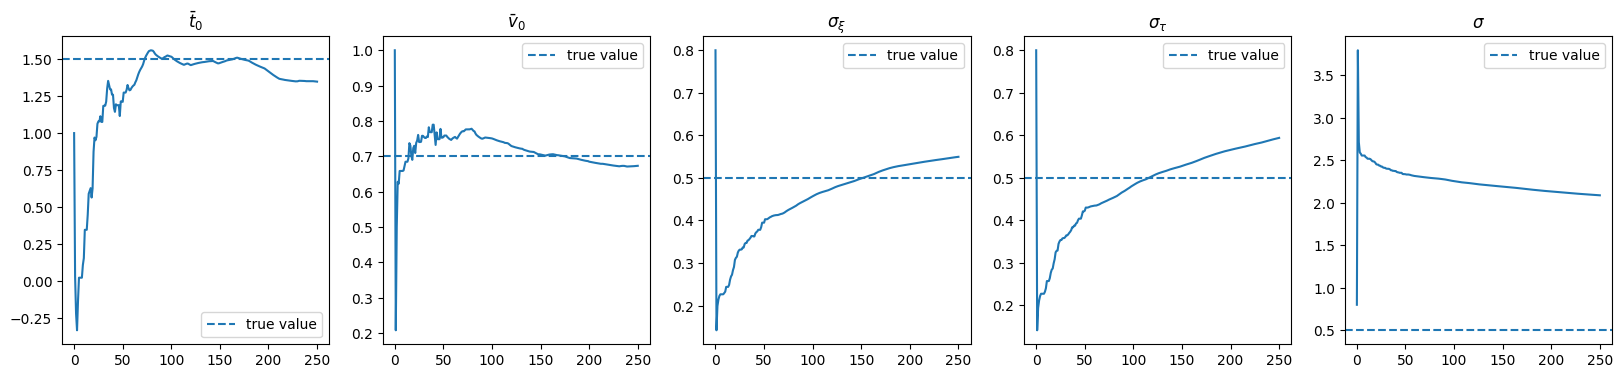

In [27]:
fig, axs = plt.subplots(1, 5, figsize=(20,4))

for i, j in enumerate(["$\\bar t_0$", "$\\bar v_0$", "$\\sigma_{\\xi}$", "$\\sigma_{\\tau}$", "$\\sigma$"]):
  axs[i].plot(ITERATES_THETA[:,i])
  axs[i].axhline(y=TRUE_THETA[i], linestyle='--', label='true value')
  axs[i].legend()
  axs[i].set_title(j)

## 5.

From previous questions, we have that for all $i$,
$$\log\pi_i(z_i)=\log p(z_i|z_{pop},y,\theta)=-\frac{1}{2\sigma^2}\sum_{j}(y_{i,j}-d_i(t_{i,j}))^2-\frac{\xi_i^2}{2\sigma_\xi^2}-\frac{\tau_i^2}{2\sigma_\tau^2}+C_i$$
where $C_i$ is a constant independent of $z_i$.

Thus, the Metropolis-Hastings to sample $z_i|z_{pop},y,\theta$ within Gibbs sampler is:

1.   Propose a candidate $z_i^*=(\xi_i^*,\tau_i^*)\sim\mathcal N(z_i^{(k)},\sigma_{prop})$
2. Compute the log-acceptance ratio
$$\log \alpha = \min\Big(0, \log \pi_i(z_i^*)- \log \pi_i(z_i^{(k)})\Big)$$
3. Sample $u\sim\mathcal U ([0,1])$.
4. If $\log u \le \log\alpha$, set $z_i^{(k+1)}=z_i^*$.
5. Else, set $z_i^{(k+1)}=z_i^{(k)}$.

In [28]:
def HMwG_z_i(i, current_z_i, z_pop, y, theta, t, sigma_prop):
  '''Metropolis-Hastings within Gibbs (MHwG) step to update the random effects
  $z_i = (xi_i, tau_i)$ for a single individual $i$.'''

  bar_t_0, bar_v_0, sigma_xi, sigma_tau, sigma = theta
  t_0, v_0 = z_pop
  current_alpha_i, current_tau_i = current_z_i

  # Define the log pi i function
  log_pi_i = lambda xi_i, tau_i: -1/(2*sigma**2) * np.sum((y[i] - P_0 - v_0 * np.exp(xi_i) * (t[i] - t_0 - tau_i))**2) - xi_i**2 / (2*sigma_xi**2) - tau_i**2 / (2*sigma_tau**2)

  # Propose a candidate
  proposed_xi_i = np.log(current_alpha_i) + np.random.normal(scale=sigma_prop)
  proposed_tau_i = current_tau_i + np.random.normal(scale=sigma_prop)

  # Compute the log-acceptance ratio
  log_acceptance_ratio = min(0, log_pi_i(proposed_xi_i, proposed_tau_i) - log_pi_i(np.log(current_alpha_i), current_tau_i))

  # Update
  u = np.random.random()
  if np.log(u) <= log_acceptance_ratio:
    return (np.exp(proposed_xi_i), proposed_tau_i)
  else:
    return (current_alpha_i, current_tau_i)

## 6.
For $z_{pop}=(t_0,v_0)$. We have that
$$\log\pi_{pop}(z_{pop})=\log p(z_{pop}|z_i, y, \theta)=-\frac{1}{2\sigma^2}\sum_{i,j}(y_{i,j}-p_0-v_0\alpha_i(t_{i,j}-t_0-\tau_i))^2-\frac{(t_0-\bar t_0)^2}{2\sigma_{t_0}^2}-\frac{(v_0-\bar v_0)^2}{2\sigma_{v_0}^2}$$

The HM step is similar to previously, but with this new log-density function.

In [29]:
def HMwG_z_pop(current_z_pop, z_i, y, theta, t, sigma_prop):
  '''Metropolis-Hastings within Gibbs (MHwG) step to update the random effects
  $z_pop = (t_0, v_0)$.'''

  bar_t_0, bar_v_0, sigma_xi, sigma_tau, sigma = theta
  alpha, tau = z_i[:,0], z_i[:,1]
  current_t_0, current_v_0 = z_pop

  # Define the log pi i function
  log_pi_pop = lambda t_0, v_0: -1/(2*sigma**2) * np.sum((y - P_0 - v_0 * alpha[:,None] * (t - t_0 - tau[:,None]))**2) - (t_0 - bar_t_0)**2 / (2*SIGMA_t_0**2) - (v_0 - bar_v_0)**2 / (2*SIGMA_v_0**2)

  # Propose a candidate
  proposed_t_0 = current_t_0 + np.random.normal(scale=sigma_prop)
  proposed_v_0 = current_v_0 + np.random.normal(scale=sigma_prop)

  # Compute the log-acceptance ratio
  log_acceptance_ratio = min(0, log_pi_pop(proposed_t_0, proposed_v_0) - log_pi_pop(current_t_0, current_v_0))

  # Update
  u = np.random.random()
  if np.log(u) <= log_acceptance_ratio:
    return (proposed_t_0, proposed_v_0)
  else:
    return (current_t_0, current_v_0)

## 7.

We now modify the MCMC-SAEM algorithm we have implemented in question 4 to use this Gibbs sampler.

In [30]:
def HMwG_SAEM(Y, theta_0, epsilons, t, K, PRIOR_PARAMS):
  '''Run HMwG-SAEM algorithm on data Y, initial guess theta_0, and step sizes epsilons.
  Also requires the array t of the measurement times, the total number of measurements K
  and the prior parameters PRIOR_PARAMS.
  Returns an array containing theta^{(k)} for all iterations.'''

  HMwG_STEPS_PER_EM_ITER = 20
  SIGMA_PROP = .05

  maxIter = len(epsilons)
  N = len(Y)

  # INITIALIZATION
  THETA = np.zeros((maxIter+1, 5))
  THETA[0] = np.array(theta_0)
  z = ((0, 0), np.zeros((N, 2))) # Keep the same z_pop, z_i format as previously
  z[1][:,0] = np.ones(N) # Initalize alpha=1 instead of 0
  S = np.zeros(5)

  for k in range(maxIter):

    # 1. SIMULATION
    # Run HMwG sampler for a few steps, initialized at the current z^{(k)}
    for _ in range(HMwG_STEPS_PER_EM_ITER):
      z_pop, z_i = z
      # Sample z_pop
      z_pop = HMwG_z_pop(z_pop, z_i, y, THETA[k], t, SIGMA_PROP)
      # Sample one-by-one the z_i
      for i in range(N):
        z_i[i] = HMwG_z_i(i, z_i[i], z_pop, y, THETA[k], t, SIGMA_PROP)
      z = (z_pop, z_i)

    # 2. STOCHASTIC APPROXIMATION
    # Compute and update S
    computed_S = compute_S_from_y_z(Y, z, t, K)
    S += epsilons[k] * (computed_S - S)

    # 3. MAXIMIZATION
    THETA[k+1] = maximization_step(S, N, K, PRIOR_PARAMS)

  return THETA

## 8.

The main advantage of a Block Gibbs sampler is that it improves convergence when variables within a block (like $t_0$ and $v_0$) are highly correlated. By updating these variables simultaneously using a multivariate proposal, the sampler can explore the parameter space more efficiently and avoid the slow "zig-zag" behavior that occurs with single-variable updates.

## 9.

This implementation treats the population parameters $z_{pop}$ and each individual's effects $z_i$ as separate vector blocks, updating each block as a whole using multivariate Gaussian proposals. I actually implemented this in Question 7, as the vector notations $z_i = (\xi_i, \tau_i)$ and $z_{pop}=(t_0,v_0)$ implied a simultaneous update.

# Exercise 2: Data augmentation

### 1.

$X_n$ is sampled from the conditional density $f_{X|Y}(\cdot, Y_{n-1})$, thus we have
$$p(X_n|\mathcal F_{n-1})=p(X_n|Y_{n-1})$$
$Y_n$ is sampled from the conditional density $f_{Y|X}(X_n, \cdot)$, thus we have
$$p(Y_n|X_n, \mathcal F_{n-1})=p(Y_n|X_n)$$
Thus, the joint conditional density of (X_n, Y_n) given the past history is
$$p(X_n, Y_n|\mathcal F_{n-1})=p(X_n|\mathcal F_{n-1})p(Y_n|X_n, \mathcal F_{n-1})=p(X_n|Y_{n-1})p(Y_n|X_n)$$
Since this only depends on the previous state $(X_{n-1}, Y_{n-1})$ (actually only on $Y_{n-1}$), the process satisfies the Markov property.

Let $B$ be a Borel set of $\mathbb R^p \times \mathbb R^q$. The transition kernel of the Markov chain $((X_n, Y_n))_n$ is
$$K_{X,Y}((x,y),B)=\mathbb P((X_n,Y_n)\in B |(X_{n-1},Y_{n-1})=(x,y))$$
$$=\int_B p(x',y'|x,y)\,d(x',y')$$
$$K_{X,Y}((x,y),B)=\int_B f_{X|Y}(x',y)\,f_{Y|X}(x',y')\,d(x',y')$$

## 2.

We have shown in the last question that for all $n$, $(X_n, Y_n)$ only depends on $Y_{n-1}$. So, in particular, $Y_n$ only depends on $Y_{n-1}$. Thus, $(Y_n)_n$ is a Markov chain.



Let $B$ be a Borel set of $\mathbb R^q$. The transition kernel of the Markov chain $(Y_n)_n$ is
$$K_Y(y,B)=\mathbb P(Y_n\in B|Y_{n-1}=y)$$
$$=\int_{\mathbb R^p} \mathbb P(Y_n\in B|X_n=x, Y_{n-1}=y)\,p(X_n=x|Y_{n-1}=y)\,dx$$
$$K_Y(y,B)=\int_B \int_{\mathbb R^p} f_{Y|X}(x,y')\,f_{X|Y}(x,y)\,dx\,dy'$$

Let $B$ be a Borel set of $\mathbb R^q$. We want to show that
$$f_YK_Y(B)=\int_{\mathbb R^q}K_Y(y,B)f_Y(B)dy=f_Y(B)$$
Plugging the expression of the transition kernel of $(Y_n)_n$, we have
$$\int_{\mathbb R^q}K_Y(y,B)f_Y(B)dy=\int_{\mathbb R^q}\int_B \int_{\mathbb R^p} f_{Y|X}(x,y')\,f_{X|Y}(x,y)\,f_Y(y)\,dx\,dy'\,dy$$
Using Tonelli, we can switch integrals, which gives
$$\int_{\mathbb R^q}K_Y(y,B)f_Y(B)dy= \int_B \int_{\mathbb R^p} \int_{\mathbb R^q}  \frac{f(x,y')f(x,y)}{f_X(x)}\,dy\,dx\,dy'$$
$$= \int_B \int_{\mathbb R^p} f(x,y') \Big(\int_{\mathbb R^q}  f_{Y|X}(x,y)\,dy\Big)dx\,dy'$$
$$=\int_B \Big(\int_{\mathbb R^p} f(x,y')\,dx\Big)dy'$$
$$=\int_B f_Y(y')\,dy'$$
$$=f_Y(B)$$
Thus, $f_Y(\cdot)$ is invariant for $K_Y$.

### 3.

For such a distribution, we have:

* For $f_{X|Y}$:
$$f_{X|Y}(x,y) \propto \exp\Big(-y\frac{x^2}{2}\Big)$$
We recognize a Normal distribution of mean $0$ and variance $1/y$.

* For $f_{Y|X}$:
$$f_{Y|X}(x,y)\propto y^{\alpha-1}e^{-\lambda y}$$
with $\alpha=5/2$ and $\beta=x^2/2+2$. This is the density of a Gamma distribution with shape $\alpha=5/2$ and rate $\beta=x^2/2+2$.


Based on Algorithm 4, the Gibbs algorithm to sample from this distribution is:


* Let $Y_0\geq0$ and $N\in\mathbb N$.
* For $n=1, ..., N$ do:
    1. Sample $X_n\sim \mathcal N(0,\frac{1}{Y_{n-1}})$.
    2. Sample $Y_n\sim \Gamma(\frac{5}{2}, \frac{X_n^2}{2}+2)$.



We now implement the algorithm

In [31]:
def gibbs_algorithm(Y_0, N):
  '''Implement Algorithm 4 for the distribution whose density is
  $f(x,y) = 4/sqrt(2 pi) y^{3/2} exp(-y(x^2/2+2))$.
  Returns an array of shape (N, 2) containing all iterates.'''

  iterates = np.zeros((N, 2))
  y = Y_0

  for n in range(N):
    x = np.random.normal(scale=np.sqrt(1/y))
    y = np.random.gamma(shape=5/2, scale=1/(x**2/2+2))
    iterates[n] = np.array((x, y))

  return iterates

In [32]:
N = 1000
Y_0 = 0.1

iterates = gibbs_algorithm(Y_0, N)

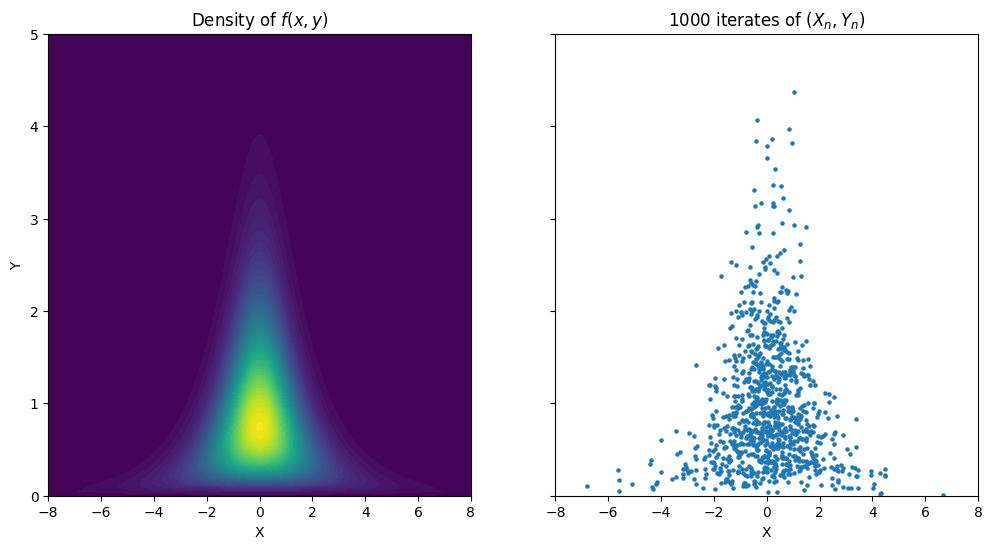

In [33]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

x_lim = (-8, 8)
y_lim = (0, 5)

# -- PLOT THE VALUE OF F --
x_vals = np.linspace(x_lim[0], x_lim[1], 100)
y_vals = np.linspace(y_lim[0], y_lim[1], 100)
X, Y = np.meshgrid(x_vals, y_vals)
f = lambda x, y: 4/np.sqrt(2*np.pi) * y**(3/2) * np.exp(-y*(x**2/2+2))
Z = f(X, Y)
axs[0].contourf(X, Y, Z, levels=50, cmap='viridis')
axs[0].set_title('Density of $f(x,y)$')

# -- PLOT THE POINTS GENERATED BY OUR ALGORITHM --
axs[1].scatter(iterates[:,0], iterates[:,1], s=5, marker='o')
axs[1].set_title('1000 iterates of $(X_n,Y_n)$')

axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[1].set_xlabel('X')
plt.xlim(x_lim)
plt.ylim(y_lim)
plt.show()

### 4.

For all $x\in\mathbb R$, we have that
$$f_X(x)=\int_{\mathbb R} f(x,y)dy=\frac{4}{\sqrt{2\pi}}\Gamma(\frac 52)\big(\frac{x^2}{2}+2\big)^{-5/2}=\frac{12}{(x^2+4)^{5/2}}$$
Thus, for all bounded function $H$ on $\mathbb R$,
$$\int_{\mathbb R} \frac{H(x)}{(4+x^2)^{5/2}}=\frac{1}{12}\mathbb E_{(X,Y)\sim f}[H(X)]$$
Hence, we can approximate this integral by
$$\frac{1}{12 N}\sum_{i=1}^N H(X_n)$$
from the output $\{(X_n,Y_n),n\}$ of the Gibbs sampler.

# Exercise 3: Multiplicative Hasting-Metropolis

### 1.

We want to determine the density of $Y|X$. Let $h$ be a bounded measurable function.
$$\mathbb E[h(Y)]=\frac 12 \mathbb E[h(\varepsilon X)]+\frac 12 \mathbb E[h(X/\varepsilon)]$$
$$=\frac 1 2 \int_{-1}^1 h(t X) f(t) dt+\frac 12 \int_{-1}^1 h(X/t) f(t) dt$$
$$=\frac{1}{2X} \int_{-|X|}^{|X|} h(s) f(s/X)ds + \frac{1}{2}\Big(\int_{-\infty}^{-|X|} h(u)\frac{f(X/u)}{u^2}du+\int_{|X|}^{+\infty} h(u)\frac{f(X/u)}{u^2}du\Big)$$
$$=\int h(s) \Big[\frac{1}{2|X|}f\Big(\frac{s}{X}\Big)\mathbf 1\{|s|\le |X|\}+\frac{|X|}{2s^2}f\Big(\frac{X}{s}\Big)\mathbf 1\{|s|\ge |X|\}\Big]\,ds$$
Thus, $Y|X$ has density
$$y\mapsto\frac{1}{2|X|}f\Big(\frac{y}{X}\Big)\mathbf 1\{|y|\le |X|\}+\frac{|X|}{2y^2}f\Big(\frac{X}{y}\Big)\mathbf 1\{|y|\ge |X|\}$$

### 2.

In the Metropolis-Hastings algorithm, the acceptation ratio $\alpha$ for the target distribution $\pi$ and the proposal distribution $q(X,\cdot)$ is
$$\alpha=\min\Big(1,\frac{\pi(Y)\,q(Y,X)}{\pi(X)\,q(X,Y)}\Big)$$
Let us compute the ratio $q(Y,X)/q(X,Y)$ with a case disjunction:
* If $|Y|\ge|X|$, i.e $Y=X/\varepsilon$,
$$\frac{q(Y,X)}{q(X,Y)}=\frac{\frac{1}{2|Y|}f(\frac{X}{Y})}{\frac{|X|}{2Y^2}f(\frac X Y)}=\frac{|Y|}{|X|}$$
* If $|Y|\le|X|$, i.e $Y=\varepsilon X$,
$$\frac{q(Y,X)}{q(X,Y)}=\frac{\frac{|Y|}{2X^2}f(\frac Y X)}{\frac 1 {2|X|}f(\frac Y X)}=\frac{|Y|}{|X|}$$

Thus, in all cases,
$$\alpha=\min\Big(1,\frac{\pi(Y)\,|Y|}{\pi(X)\,|X|}\Big)$$

### 3. et 4.

In [34]:
def multiplicative_HM(target_distrib_density, n_iter, x0, epsilon_sampler=lambda: np.random.uniform(-1, 1)):
  '''Run Multiplicative Hastings-Metropolis with n_iter iterations.
  Arguments:
    target_distrib_denity: function float -> positive float, can be defined up to a constant
    n_iter: int, number of iterations
    x0: float, initial value
    epsilon_sampler: function None -> float, sampler for epsilon, by default a uniform on [-1,1]
  Returns the list of iterates.'''

  iterates = [x0]

  for _ in range(n_iter):
    X = iterates[-1]

    # Sample epsilon and B
    epsilon = epsilon_sampler()
    B = np.random.binomial(n=1, p=0.5)
    if B:
      Y = epsilon * X
    else:
      Y = X / epsilon

    # Define the acceptance ratio
    try:
      alpha = min(1, target_distrib_density(Y) * abs(Y) / (target_distrib_density(X) * abs(X)))
    except OverflowError: # Catch overflow errors
      alpha = 0

    # Update
    u = np.random.random()
    if u <= alpha:
      iterates.append(Y)
    else:
      iterates.append(X)

  return iterates

For the distribution, from which we can sample using the inverse transform method, we will use the standard Cauchy distribution
$$\pi_1(x) \propto \frac{1}{1+x^2}$$
We can show that its inverse CDF is
$$F^{-1}:t\mapsto\tan(\pi \,t-\frac\pi 2)$$
The second distribution we will use will be the standard normal distribution
$$\pi_2(x) \propto \exp\Big(-\frac{x^2}2\Big)$$
Note that we do not need to normalize the densities in order to use Metropolis-Hastings. We only do it in order to compare the histograms of the samples with the true distribution.

In [35]:
cauchy_distrib_density = lambda x: 1/np.pi/(1+x**2)
normal_distrib_density = lambda x: 1/np.sqrt(2*np.pi)*np.exp(-x**2/2)

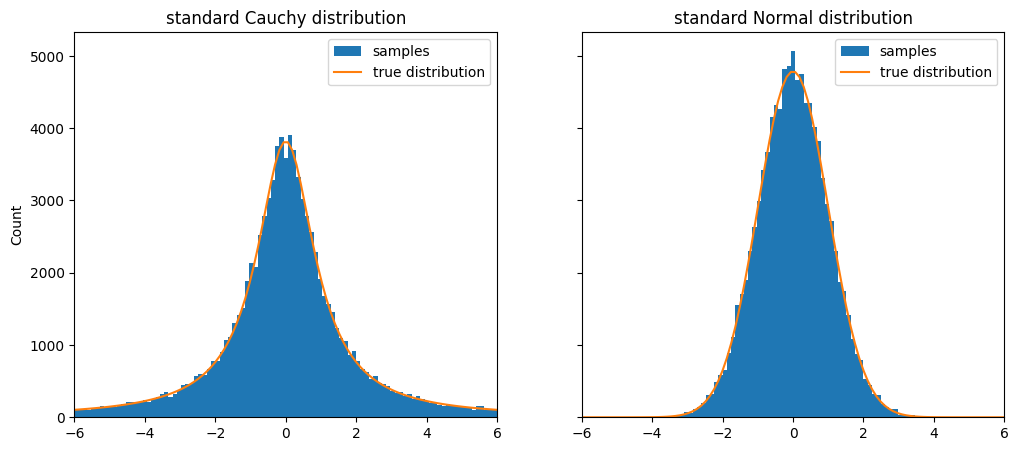

In [36]:
N_ITERATES = 100000

fig, axs = plt.subplots(1, 2, figsize=(12,5), sharex=True, sharey=True)
xlim = (-6, 6)

# CAUCHY DISTRIBUTION
iterates = multiplicative_HM(cauchy_distrib_density, N_ITERATES, 1)
axs[0].hist(iterates, bins=np.linspace(xlim[0], xlim[1], 100), density=False, label='samples')
x = np.linspace(xlim[0], xlim[1], 100)
axs[0].plot(x, cauchy_distrib_density(x) * (N_ITERATES/100*12), label='true distribution')
axs[0].legend()
axs[0].set_title('standard Cauchy distribution')

# NORMAL DISTRIBUTION
iterates = multiplicative_HM(normal_distrib_density, N_ITERATES, 1)
axs[1].hist(iterates, bins=np.linspace(xlim[0], xlim[1], 100), density=False, label='samples')
x = np.linspace(xlim[0], xlim[1], 100)
axs[1].plot(x, normal_distrib_density(x) * (N_ITERATES/100*12), label='true distribution')
axs[1].legend()
axs[1].set_title('standard Normal distribution')

axs[0].set_ylabel('Count')
plt.xlim(xlim)
plt.show()

The samples perfectly match with the true distribution.